In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
plt.rcParams['figure.figsize'] = (8, 5)

plt.rcParams['axes.axisbelow'] = True
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.ymargin'] = 0.1

plt.rcParams['font.family'] = 'serif'

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'lightgrey'
plt.rcParams['grid.linewidth'] = .1

plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = .5
plt.rcParams['xtick.minor.visible'] = True

plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['ytick.minor.width'] = .5
plt.rcParams['ytick.minor.visible'] = True

plt.rcParams['legend.fontsize'] = 16

plt.rcParams['lines.linewidth'] = 4
plt.rcParams['lines.markersize'] = 10

In [ ]:
plt.style.use('tableau-colorblind10')
plt.ion()

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/roualdes/data/master/possum.csv')
df.head()

,site,pop,sex,age,headL,skullW,totalL,tailL
0,1,vic,m,8.0,94.1,60.4,89.0,36.0
1,1,vic,f,6.0,92.5,57.6,91.5,36.5
2,1,vic,f,6.0,94.0,60.0,95.5,39.0
3,1,vic,f,6.0,93.2,57.1,92.0,38.0
4,1,vic,f,2.0,91.5,56.3,85.5,36.0


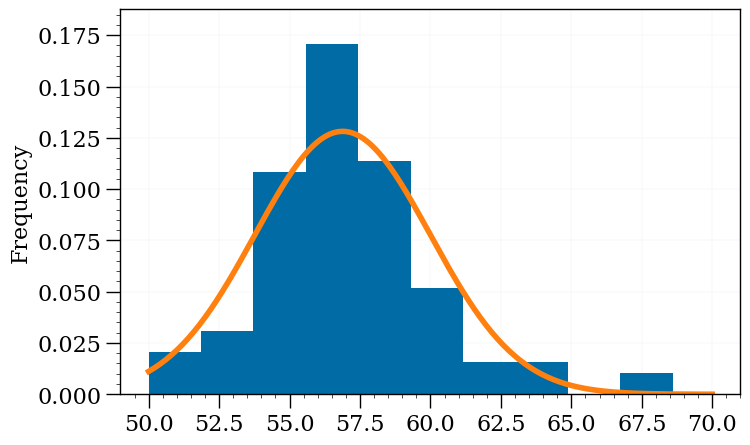

In [ ]:
df['skullW'].plot.hist(bins=10, density=True)
from scipy import stats as ss
x = np.linspace(50, 70, 200)
nrm = ss.distributions.norm(loc=df['skullW'].mean(), scale=df['skullW'].std())
plt.plot(
    x, nrm.pdf(x)
)

In [ ]:
nrm = ss.distributions.norm(loc=50, scale=1)
nrm.pdf(df['skullW'])

array([1.30096162e-24, 1.14415649e-13, 7.69459863e-23, 4.51354368e-12,
       9.60143337e-10, 3.96129909e-06, 9.99837875e-16, 1.14415649e-13,
       9.60143337e-10, 5.05227108e-15, 2.20798996e-12, 6.18262050e-08,
       2.08117682e-22, 1.14415649e-13, 1.14415649e-13, 6.07588285e-09,
       3.72263922e-69, 3.51395509e-08, 1.85736184e-07, 9.60143337e-10,
       2.25880940e-15, 8.16623563e-17, 3.31788424e-09, 2.43896075e-06,
       8.16623563e-17, 1.02797736e-18, 1.59837411e-05, 3.63096150e-11,
       6.07588285e-09, 2.49424713e-05, 8.92616572e-05, 7.13132812e-11,
       1.01408521e-05, 3.51395509e-08, 1.11879562e-14, 6.60457986e-20,
       3.96129909e-06, 6.07588285e-09, 1.29517596e-01, 1.48671951e-06,
       9.13472041e-12, 8.92616572e-05, 1.07697600e-07, 1.29517596e-01,
       1.10157636e-08, 2.49424713e-05, 3.96129909e-06, 5.82337560e-39,
       1.66558803e-19, 5.08814028e-10, 3.87811193e-21, 2.11881925e-27,
       2.25880940e-15, 7.99882776e-38, 5.82337560e-39, 7.64165541e-30,
      

In [ ]:
df[['headL', 'tailL']].mean()

headL    92.602885
tailL    37.009615
dtype: float64

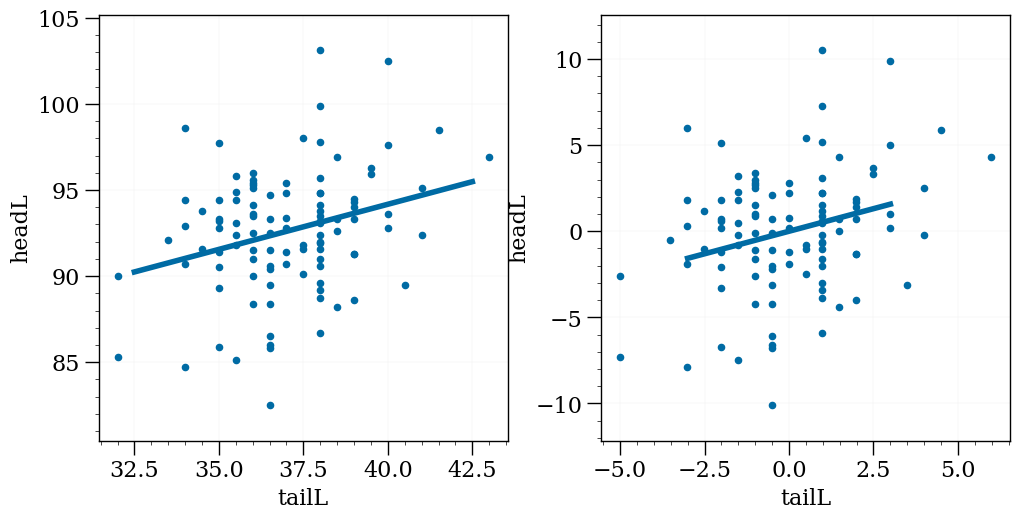

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
df[['headL', 'tailL']].plot.scatter(x='tailL', y='headL', ax=ax[0])

z = df[['headL', 'tailL']]

z = (z - z.mean()) #/ z.std(ddof=1)
z.plot.scatter(x='tailL', y='headL', ax=ax[1])
fig.tight_layout(pad=0)

cov = z.cov(ddof=1)['headL']['tailL']
var_x = z.var(ddof=1)['tailL']
b = cov / var_x
a = df['headL'].mean() - b * df['tailL'].mean()

x_line = np.linspace(-3, 3)
y = b * x_line
ax[1].plot(x_line, y)

x_line = np.linspace(32.5, 42.5)
y = a + b * x_line
ax[0].plot(x_line, y)

In [ ]:
cov = z.cov(ddof=1)['headL']['tailL']
var_x = z.var(ddof=1)['tailL']

cov / var_x

0.5241520993897548

In [ ]:
df_naonorm = df[['headL', 'tailL']]

cov = df_naonorm.cov(ddof=1)['headL']['tailL']
var_x = df_naonorm.var(ddof=1)['tailL']

cov / var_x

0.5241520993897539

<Axes: ylabel='Density'>

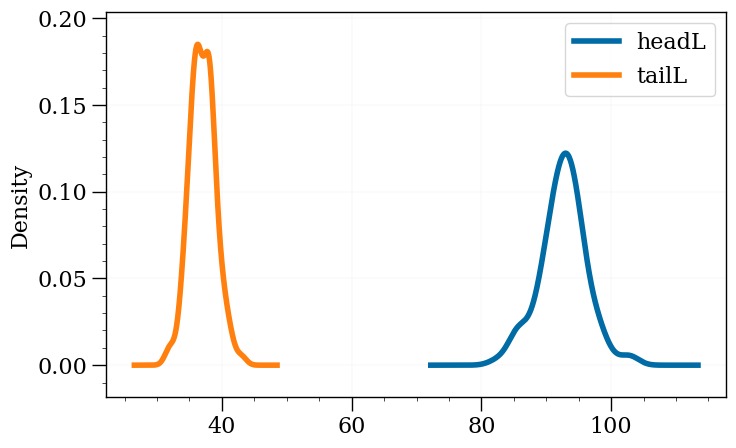

In [ ]:
df_naonorm = df[['headL', 'tailL']].plot.kde()

<Axes: ylabel='Density'>

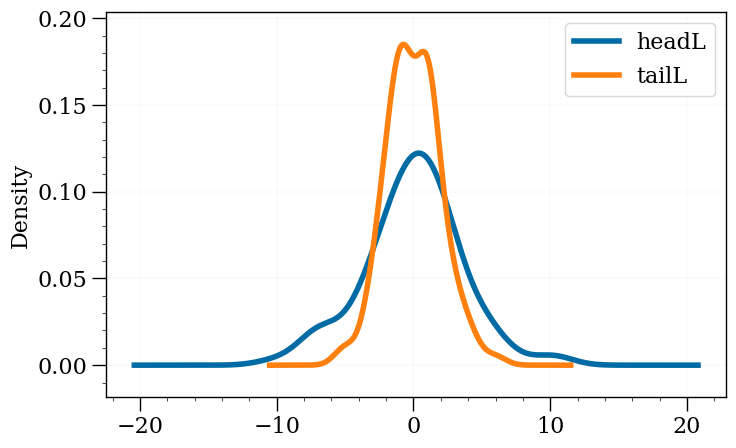

In [ ]:
z.plot.kde()

In [ ]:
z.mean()

headL   -9.564998e-15
tailL   -2.186285e-15
dtype: float64

In [ ]:
df['tailL'].std(ddof=1)

1.959518428592603

In [ ]:
df['totalL'].mean()

87.08846153846154

In [ ]:
df['totalL'].std(ddof=1)

4.310549436569344

In [ ]:
from scipy.stats import pearsonr

pearsonr(
    df.tailL,
    df.totalL
)

2.4382429157569225

[Text(0.5, 0, 'Tail Length (cm)'), Text(0, 0.5, 'Total Length (cm)')]

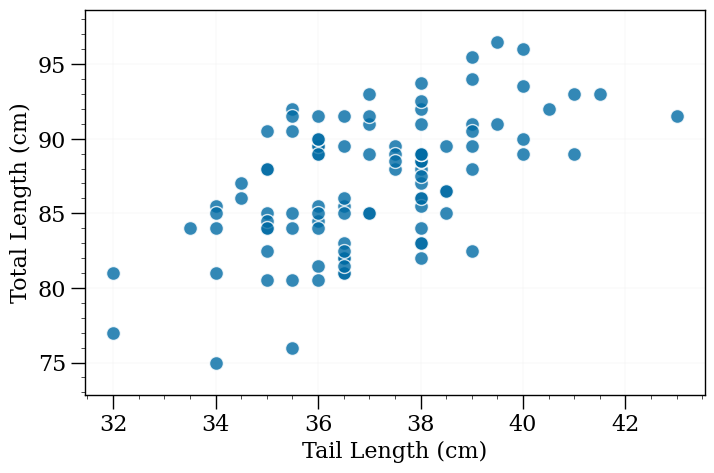

In [ ]:
plt.scatter(
    df.tailL,
    df.totalL,
    edgecolor='w',
    alpha=0.8
)
plt.gca().set(xlabel='Tail Length (cm)', ylabel='Total Length (cm)')

In [ ]:
inclinacao = pearsonr(df.tailL, df.totalL)[0] * df.totalL.std(ddof=1) / df.tailL.std(ddof=1)
inclinacao

1.2443072135372346

In [ ]:
from scipy.stats import linregress
linregress(df.tailL, df.totalL)

LinregressResult(slope=1.2443072135372344, intercept=41.03713014514601, rvalue=0.5656455056684047, pvalue=3.935378171391183e-10, stderr=0.17961891545738481, intercept_stderr=6.656848633945601)

<Axes: xlabel='tailL', ylabel='totalL'>

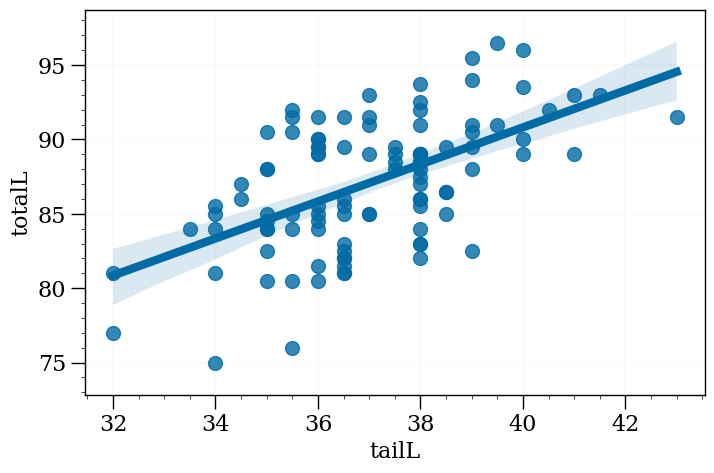

In [ ]:
import seaborn as sns
sns.regplot(df, x='tailL',y='totalL')

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
mod = smf.ols(formula='totalL ~ tailL', data=df)
print(mod.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                 totalL   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     47.99
Date:                Thu, 01 Jun 2023   Prob (F-statistic):           3.94e-10
Time:                        23:15:43   Log-Likelihood:                -278.97
No. Observations:                 104   AIC:                             561.9
Df Residuals:                     102   BIC:                             567.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.0371      6.657      6.165      0.0

In [ ]:
from scipy.stats import pearsonr
r = pearsonr(
    df.tailL,
    df.totalL
)
r

PearsonRResult(statistic=0.5656455056684044, pvalue=3.935378171391254e-10)

In [ ]:
beta = r * df.tailL.std(ddof=1) / df.totalL.std(ddof=1)
alpha = df.tailL.mean() - beta * df.totalL.mean()
x = df.totalL.unique().copy()
x.sort()
y = alpha + beta * x

TypeError: ignored

NameError: ignored

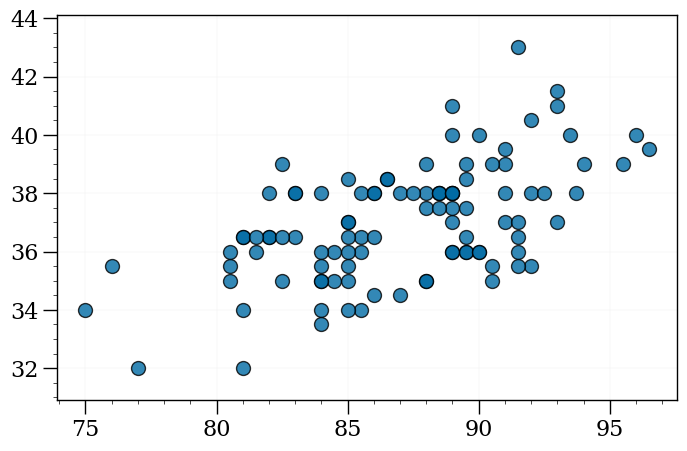

In [ ]:
plt.scatter(
    df.totalL,
    df.tailL,
    edgecolor='k',
    alpha=0.8
)
plt.plot(x, y, color='magenta')
plt.hlines(df.tailL.mean(), 75, 97, color='orange')

In [ ]:
x = df.totalL
y = alpha + beta * x
((y - df.headL) ** 2).sum()

NameError: ignored

In [ ]:
((df.headL - df.headL.mean()) ** 2).sum()

1315.1891346153843

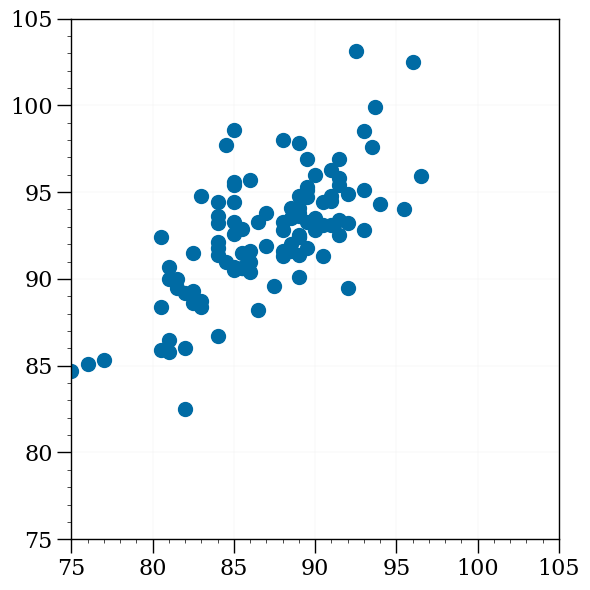

In [ ]:
plt.subplots(figsize=(6, 6))
y_efeito = df.headL #- df.headL.mean()) / df.headL.std(ddof=1)
x_causa = df.totalL #- df.totalL.mean()) / df.totalL.std(ddof=1)
plt.gca().set(xlim=(75, 105), ylim=(75, 105))
plt.scatter(x_causa, y_efeito)
plt.tight_layout()

In [ ]:
import scipy.stats as ss
r = ss.pearsonr(x_causa, y_efeito)[0]
b = r * y_efeito.std(ddof=1) / x_causa.std(ddof=1)
a = y_efeito.mean() - b * x_causa.mean()

In [ ]:
x = np.linspace(75, 105)
ŷ = b * x + a

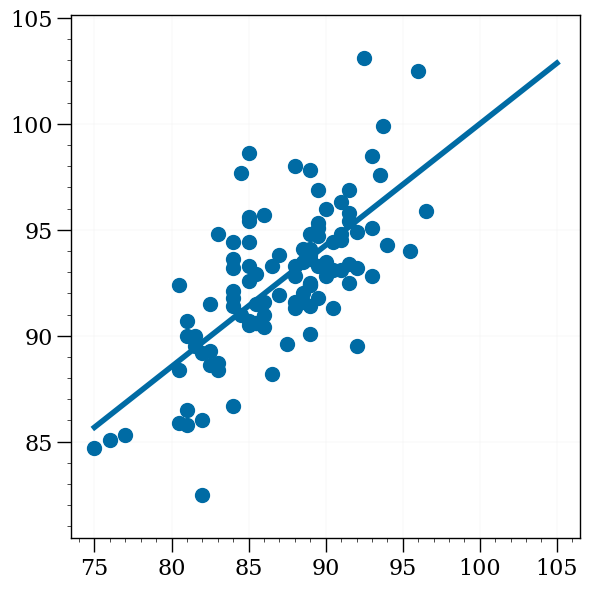

In [ ]:
plt.subplots(figsize=(6, 6))

plt.scatter(x_causa, y_efeito)
plt.plot(x, ŷ)

plt.tight_layout()